In [661]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Chargement des données¶

In [663]:
df = pd.read_csv('/Users/bakarybengaly/Documents/fluxapp_projet_clean/customers.csv')
df.head()

,customer_id,plan,acquisition_channel,country,age,tenure_months,monthly_spend_eur,sessions_last30d,support_tickets,churned
0,1,Pro,Ads,FR,19.0,30,26.01,16,0,1
1,2,Business,Referral,CA,47.0,16,81.05,21,2,0
2,3,Pro,Organic,CH,38.0,27,26.19,10,1,1
3,4,Basic,Organic,CA,44.0,31,10.79,10,0,0
4,5,Basic,Organic,Autre,64.0,12,11.09,8,1,1


### 1.2 Exploration initiale¶

In [665]:
df.shape

(1500, 10)

In [666]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          1500 non-null   int64  
 1   plan                 1500 non-null   object 
 2   acquisition_channel  1500 non-null   object 
 3   country              1500 non-null   object 
 4   age                  1480 non-null   float64
 5   tenure_months        1500 non-null   int64  
 6   monthly_spend_eur    1480 non-null   float64
 7   sessions_last30d     1500 non-null   int64  
 8   support_tickets      1500 non-null   int64  
 9   churned              1500 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 117.3+ KB


### 1.3 Traitement des valeurs manquantes¶

In [668]:
age_mediane = df['age'].median()
print(f"Médiane de l'âge : {age_mediane}")


Médiane de l'âge : 41.0


In [669]:
df['age'] = df['age'].fillna(age_mediane)
print("valeur manquante de l'âge est" ,df['age'].isnull().sum())

valeur manquante de l'âge est 0


In [670]:
mediane_par_plan = df.groupby('plan')['monthly_spend_eur'].median()
print(mediane_par_plan)

plan
Basic        9.100
Business    79.160
Pro         28.755
Name: monthly_spend_eur, dtype: float64


In [671]:
df['monthly_spend_eur'] = df.groupby('plan')['monthly_spend_eur'].transform(
    lambda x: x.fillna(x.median())
)
print("Valeurs manquantes restantes dans monthly_spend_eur", df['monthly_spend_eur'].isnull().sum())

Valeurs manquantes restantes dans monthly_spend_eur 0


In [672]:
df.isnull().sum()

customer_id            0
plan                   0
acquisition_channel    0
country                0
age                    0
tenure_months          0
monthly_spend_eur      0
sessions_last30d       0
support_tickets        0
churned                0
dtype: int64

### 1.3 Statistiques descriptives

In [674]:
df.describe()

,customer_id,age,tenure_months,monthly_spend_eur,sessions_last30d,support_tickets,churned
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,750.500000,41.214667,18.116000,24.605913,12.973333,1.25000,0.387333
std,433.157015,13.600879,10.192275,23.192640,4.065584,1.10347,0.487303
min,1.000000,18.000000,1.000000,5.000000,3.000000,0.00000,0.000000
25%,375.750000,30.000000,9.000000,8.830000,10.000000,0.00000,0.000000
50%,750.500000,41.000000,18.000000,12.800000,13.000000,1.00000,0.000000
75%,1125.250000,53.000000,27.000000,29.882500,15.000000,2.00000,1.000000
max,1500.000000,64.000000,35.000000,85.760000,27.000000,6.00000,1.000000


In [675]:
print("Taux de churn global est :", round(df['churned'].mean() * 100, 1), "%")
print("Nombre de clients churned est :", df['churned'].sum())
print("Nombre de clients actifs est :", (df['churned'] == 0).sum())

Taux de churn global est : 38.7 %
Nombre de clients churned est : 581
Nombre de clients actifs est : 919


### 1.4 Analyses croisées

In [677]:
print("Taux de churn par plan :")
print((df.groupby('plan')['churned'].mean() * 100).round(1))

Taux de churn par plan :
plan
Basic       46.3
Business    20.6
Pro         33.1
Name: churned, dtype: float64


In [678]:
print("Taux de churn par canal :")
print((df.groupby('acquisition_channel')['churned'].mean() * 100).round(1))

Taux de churn par canal :
acquisition_channel
Ads         43.2
Organic     38.3
Referral    37.9
Social      32.8
Name: churned, dtype: float64


In [679]:
df['tenure_bin'] = pd.cut(df['tenure_months'], 
                           bins=[0, 6, 12, 24, 60],
                           labels=['0-6 mois', '7-12 mois', '13-24 mois', '25+ mois'])

print("Taux de churn par ancienneté :")
print((df.groupby('tenure_bin', observed=True)['churned'].mean() * 100).round(1))

Taux de churn par ancienneté :
tenure_bin
0-6 mois      48.6
7-12 mois     47.0
13-24 mois    37.3
25+ mois      30.3
Name: churned, dtype: float64


### 1.5 Visualisations

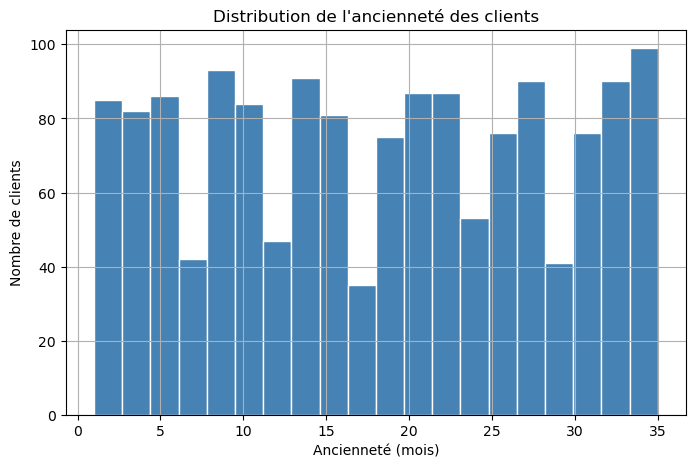

In [681]:
plt.figure(figsize=(8, 5))
df['tenure_months'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title("Distribution de l'ancienneté des clients")
plt.xlabel("Ancienneté (mois)")
plt.ylabel("Nombre de clients")
plt.show()

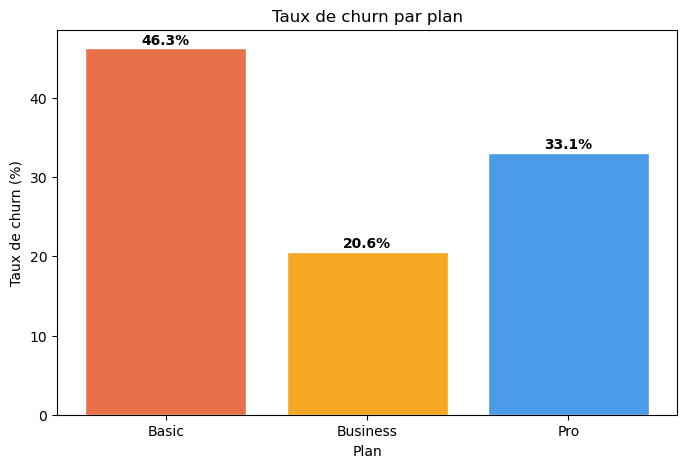

In [682]:
churn_par_plan = (df.groupby('plan')['churned'].mean() * 100).round(1)

plt.figure(figsize=(8, 5))
plt.bar(churn_par_plan.index, churn_par_plan.values, color=['#E8714C', '#F5A623', '#4C9BE8'], edgecolor='white')
plt.title("Taux de churn par plan")
plt.xlabel("Plan")
plt.ylabel("Taux de churn (%)")
for i, val in enumerate(churn_par_plan.values):
    plt.text(i, val + 0.5, f"{val}%", ha='center', fontweight='bold')
plt.show()

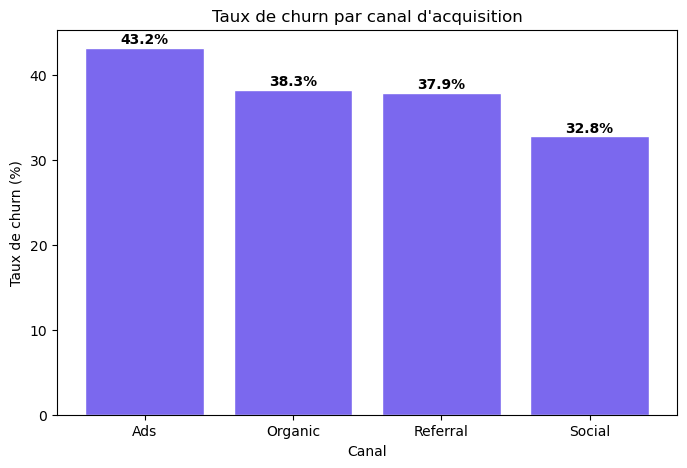

In [683]:
churn_par_canal = (df.groupby('acquisition_channel')['churned'].mean() * 100).round(1)

plt.figure(figsize=(8, 5))
plt.bar(churn_par_canal.index, churn_par_canal.values, color='#7B68EE', edgecolor='white')
plt.title("Taux de churn par canal d'acquisition")
plt.xlabel("Canal")
plt.ylabel("Taux de churn (%)")
for i, val in enumerate(churn_par_canal.values):
    plt.text(i, val + 0.5, f"{val}%", ha='center', fontweight='bold')
plt.show()

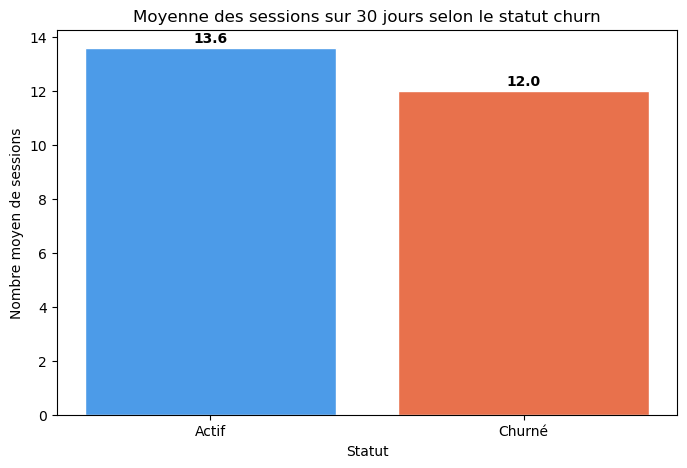

In [684]:
sessions_churn = df.groupby('churned')['sessions_last30d'].mean().round(1)

plt.figure(figsize=(8, 5))
plt.bar(['Actif', 'Churné'], sessions_churn.values, 
        color=['#4C9BE8', '#E8714C'], edgecolor='white')
plt.title("Moyenne des sessions sur 30 jours selon le statut churn")
plt.xlabel("Statut")
plt.ylabel("Nombre moyen de sessions")
for i, val in enumerate(sessions_churn.values):
    plt.text(i, val + 0.2, f"{val}", ha='center', fontweight='bold')
plt.show()

### 1.6 Constats clés

1. **Taux de churn global élevé (38.7%)** : près de 2 clients sur 5 ont résilié, ce qui représente un risque majeur pour FluxApp.

2. **Le plan Basic concentre le churn (46.3%)** : les clients à faible dépense partent beaucoup plus que les clients Business (20.6%), suggérant une valeur perçue insuffisante.

3. **Le canal Ads est le plus problématique (43.2%)** : les clients recrutés via publicité payante sont moins fidèles que ceux issus du Social (32.8%).

4. **L'engagement est un signal fort** : les clients actifs font en moyenne 13.6 sessions contre 12.0 pour les churnés — moins un client utilise l'application, plus il risque de partir.

5. **L'ancienneté protège contre le churn** : les clients de plus de 25 mois churnen à 30.3% contre 48.6% pour les nouveaux clients (0-6 mois).

## Bloc 2 — Analytics et optimisation

### 2.1 KPIs produit : MRR et ARPU par canal

In [688]:
df_actif = df[df['churned'] == 0]
MRR = df_actif['monthly_spend_eur'].sum().round(2)
print( " le Revenu Mensuel Récurrent est", MRR, "EUR")

 le Revenu Mensuel Récurrent est 25703.84 EUR


In [689]:
arpu_canal = df_actif.groupby('acquisition_channel')['monthly_spend_eur'].mean().round(2)
print("Revenu Moyen Par Utilisateur est " , arpu_canal)


Revenu Moyen Par Utilisateur est  acquisition_channel
Ads         27.57
Organic     27.18
Referral    29.26
Social      28.58
Name: monthly_spend_eur, dtype: float64


In [690]:
churn_canal = (df.groupby('acquisition_channel')['churned'].mean() * 100).round(1)
print("Taux de churn par canal :" , churn_canal)


Taux de churn par canal : acquisition_channel
Ads         43.2
Organic     38.3
Referral    37.9
Social      32.8
Name: churned, dtype: float64


### 2.2 Coût d'acquisition (CAC) et LTV

**Rappel des indicateurs :**
- **CAC** (Customer Acquisition Cost) : coût pour recruter un nouveau client
- **LTV** (Lifetime Value) : revenu total généré par un client sur toute sa durée de vie
- **LTV/CAC** : ratio de rentabilité — un ratio >= 3 est considéré comme bon

In [692]:
mkt = pd.read_csv('/Users/bakarybengaly/Documents/fluxapp_projet_clean/marketing_spend.csv')
print(mkt)


    channel  spend_eur  new_customers
0   Organic          0            520
1       Ads      18000            426
2  Referral       4000            319
3    Social       9000            235


In [693]:
mkt['cac'] = mkt['spend_eur'] / mkt['new_customers']
print("cout d'acquisition clients par canal :")
print(mkt[['channel', 'spend_eur', 'new_customers', 'cac']].to_string(index=False))

cout d'acquisition clients par canal :
 channel  spend_eur  new_customers       cac
 Organic          0            520  0.000000
     Ads      18000            426 42.253521
Referral       4000            319 12.539185
  Social       9000            235 38.297872


In [694]:
arpu_canal2 = df_actif.groupby('acquisition_channel')['monthly_spend_eur'].mean()
churn_canal2 = df.groupby('acquisition_channel')['churned'].mean()

mkt = mkt.rename(columns={'channel': 'acquisition_channel'})

mkt['arpu'] = mkt['acquisition_channel'].map(arpu_canal2)
mkt['churn_rate'] = mkt['acquisition_channel'].map(churn_canal2)
mkt['ltv'] = (mkt['arpu'] * 0.80) / mkt['churn_rate']

print(mkt[['acquisition_channel', 'cac', 'arpu', 'churn_rate', 'ltv']].round(2).to_string(index=False))

acquisition_channel   cac  arpu  churn_rate   ltv
            Organic  0.00 27.18        0.38 56.81
                Ads 42.25 27.57        0.43 51.06
           Referral 12.54 29.26        0.38 61.71
             Social 38.30 28.58        0.33 69.77


In [695]:
mkt['ltv_cac'] = (mkt['ltv'] / mkt['cac']).round(2)
print(mkt[['acquisition_channel', 'cac', 'ltv', 'ltv_cac']].round(2).to_string(index=False))

acquisition_channel   cac   ltv  ltv_cac
            Organic  0.00 56.81      inf
                Ads 42.25 51.06     1.21
           Referral 12.54 61.71     4.92
             Social 38.30 69.77     1.82


In [696]:
mkt['ltv_cac'] = mkt['ltv_cac'].replace(float('inf'), 'Gratuit')
print(mkt[['acquisition_channel', 'cac', 'ltv', 'ltv_cac']].to_string(index=False))

acquisition_channel       cac       ltv ltv_cac
            Organic  0.000000 56.814715 Gratuit
                Ads 42.253521 51.062483    1.21
           Referral 12.539185 61.707526    4.92
             Social 38.297872 69.768228    1.82


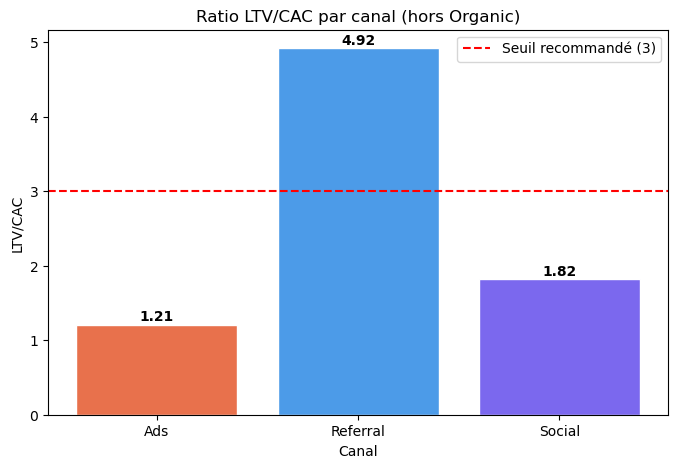

In [697]:
mkt_graph = mkt[mkt['acquisition_channel'] != 'Organic'].copy()

plt.figure(figsize=(8, 5))
plt.bar(mkt_graph['acquisition_channel'], mkt_graph['ltv_cac'].astype(float), 
        color=['#E8714C', '#4C9BE8', '#7B68EE'], edgecolor='white')
plt.axhline(y=3, color='red', linestyle='--', label='Seuil recommandé (3)')
plt.title("Ratio LTV/CAC par canal (hors Organic)")
plt.xlabel("Canal")
plt.ylabel("LTV/CAC")
plt.legend()
for i, val in enumerate(mkt_graph['ltv_cac'].astype(float)):
    plt.text(i, val + 0.05, f"{val}", ha='center', fontweight='bold')
plt.show()

### 2.3 Recommandation d'optimisation budgétaire

- **Referral** est le seul canal rentable avec un ratio LTV/CAC de 4.92 (au dessus du seuil de 3). Il faut **augmenter le budget** sur ce canal (programme ambassadeurs, incentives parrainage).
- **Ads** a le CAC le plus élevé (42.25 EUR) et le ratio LTV/CAC le plus faible (1.21). Il faut **réduire ce budget d'au moins 30%**.
- **Social** est en dessous du seuil (1.82) mais reste à surveiller avant de réduire.
- **Organic** est gratuit et performant — continuer à investir dans le SEO et le contenu.

### 2.4 Test A/B — Nouveau parcours d'onboarding

In [700]:
ab = pd.read_csv('/Users/bakarybengaly/Documents/fluxapp_projet_clean/ab_test.csv')
print(ab.head())
print(ab.shape)

  variant  converted
0       A          0
1       A          1
2       A          0
3       A          0
4       A          0
(8380, 2)


In [701]:
taux_conversion = ab.groupby('variant')['converted'].mean() * 100
print("Taux de conversion par variante :")
print(taux_conversion.round(2))

Taux de conversion par variante :
variant
A    11.88
B    13.18
Name: converted, dtype: float64


In [702]:
uplift = ((13.18 - 11.88) / 11.88) * 100
print("Uplift relatif de B par rapport à A :", round(uplift, 2), "%")

Uplift relatif de B par rapport à A : 10.94 %


#### Test statistique de proportions (z-test)

In [704]:
from statsmodels.stats.proportion import proportions_ztest

n_A = (ab['variant'] == 'A').sum()
n_B = (ab['variant'] == 'B').sum()

conv_A = ab[ab['variant'] == 'A']['converted'].sum()
conv_B = ab[ab['variant'] == 'B']['converted'].sum()

stat, pvalue = proportions_ztest([conv_B, conv_A], [n_B, n_A])

print("z-stat :", round(stat, 4))
print("p-value :", round(pvalue, 4))

z-stat : 1.7985
p-value : 0.0721


#### Conclusion du test A/B

- Variante A : 11.88% de conversion
- Variante B : 13.18% de conversion
- Uplift relatif : +10.94%
- p-value : 0.0721 > 0.05 → résultat **non significatif**

La variante B semble meilleure mais on ne peut pas en être sûr — la différence pourrait être due au hasard. Il serait risqué de déployer B sur cette base.

**Recommandation : prolonger le test avec plus d'utilisateurs pour avoir un résultat fiable avant de prendre une décision.**

## Bloc 3 — Intégration de l'IA dans les produits digitaux
### 3.1 Préparation des données

In [707]:
features_cat = ['plan', 'acquisition_channel', 'country']
features_num = ['age', 'tenure_months', 'monthly_spend_eur', 'sessions_last30d', 'support_tickets']

X = df[features_cat + features_num]
y = df['churned']

print("Variables catégorielles :", features_cat)
print("Variables numériques :", features_num)
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Variables catégorielles : ['plan', 'acquisition_channel', 'country']
Variables numériques : ['age', 'tenure_months', 'monthly_spend_eur', 'sessions_last30d', 'support_tickets']
Dimensions de X : (1500, 8)
Dimensions de y : (1500,)


In [708]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)

Taille train : (1200, 8)
Taille test : (300, 8)


#### Préparation du Pipeline

In [710]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])

### 3.2 Entraînement des modèles

In [712]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

print("Modèles entraînés !")

Modèles entraînés !


### 3.3 Évaluation des modèles

In [714]:
from sklearn.metrics import roc_auc_score, accuracy_score

for name, pipe in [('Régression Logistique', pipe_lr), ('Forêt Aléatoire', pipe_rf)]:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} | AUC-ROC = {round(auc, 4)} | Accuracy = {round(acc, 4)}")

Régression Logistique | AUC-ROC = 0.6953 | Accuracy = 0.68
Forêt Aléatoire | AUC-ROC = 0.6563 | Accuracy = 0.6533


#### Meilleur modèle : Régression Logistique

La Régression Logistique obtient le meilleur AUC-ROC (0.6953) ce qui signifie qu'elle distingue mieux les clients qui vont churner de ceux qui vont rester. On la choisit comme modèle final.

#### Matrice de confusion

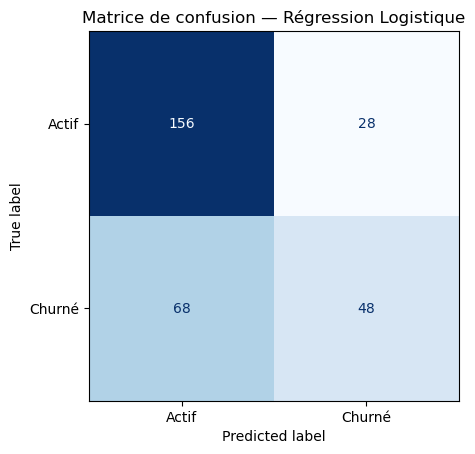

In [717]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = pipe_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Actif', 'Churné'])
disp.plot(cmap='Blues', colorbar=False)
plt.title("Matrice de confusion — Régression Logistique")
plt.show()

#### Analyse de la matrice de confusion

- Le modèle détecte correctement 48 clients churnés sur 116 (41%)
- **68 clients churnés ne sont pas détectés (faux négatifs)** — ces clients partent sans qu'on intervienne
- C'est le principal point d'amélioration du modèle

### 3.4 Interprétabilité — Variables les plus prédictives

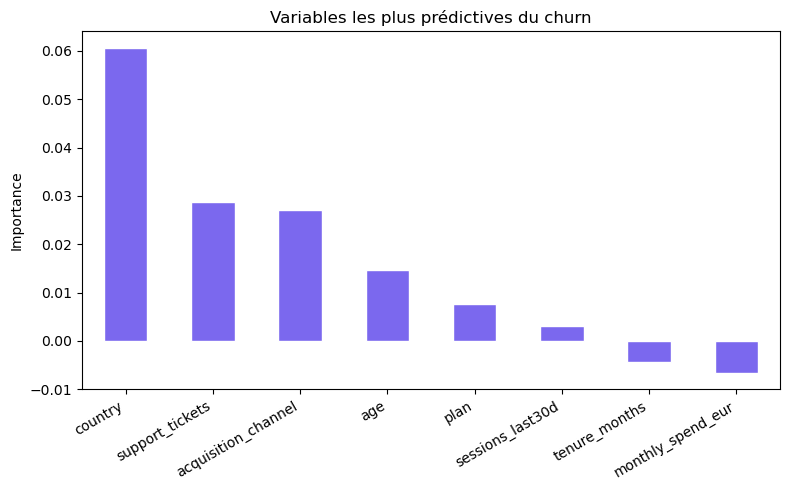

In [720]:
from sklearn.inspection import permutation_importance

result = permutation_importance(pipe_lr, X_test, y_test, n_repeats=10, random_state=42)

feature_names = features_num + features_cat
importances = pd.Series(result.importances_mean, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='#7B68EE', edgecolor='white')
plt.title("Variables les plus prédictives du churn")
plt.ylabel("Importance")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### Lien avec le Bloc 1

- **support_tickets** confirme notre analyse : les clients frustrés partent davantage
- **acquisition_channel** : on avait vu que Ads avait le churn le plus élevé (43.2%)
- **plan** : le plan Basic avait le churn le plus fort (46.3%)
- Ces résultats sont cohérents avec nos constats du Bloc 1

### 3.5 Intégration produit

#### (a) Mode de mise à disposition

Le modèle sera déployé en **batch nocturne** : chaque nuit, il calcule un score de risque de churn pour chaque client actif. Ce mode est simple à mettre en place et suffisant pour des actions marketing planifiées.

#### (b) Actions déclenchées selon le score

- **Score > 70%** : email de rétention personnalisé + offre commerciale (réduction, mois offert)
- **Score entre 50% et 70%** : notification in-app pour encourager l'utilisation de fonctionnalités peu explorées
- **Score < 50%** : aucune action, client stable

#### (c) Limites et enjeux éthiques

1. **Biais** : si certains groupes de clients sont sous-représentés dans les données d'entraînement, le modèle sera moins précis pour eux
2. **Faux positifs** : cibler des clients stables avec des offres peut les inciter à demander des réductions inutilement
3. **Dérive du modèle** : le comportement des clients évolue, le modèle doit être ré-entraîné régulièrement
4. **RGPD** : l'utilisation des données comportementales doit être conforme à la réglementation européenne